In [7]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from pathlib import Path

In [8]:
def filename(thr1, thr2):
    return data_dir / f"Train_DivBS-RhoLos_thr-{thr1}-{thr2}_epoch-75.npy"

In [9]:
data_dir = Path("../interpolation/data")
thresholds = [
    0.0,
    0.1,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
]


In [10]:
t = np.linspace(0, 1, 25)
curves = {}

for thr1, thr2 in combinations(thresholds, 2):
    path = filename(thr1, thr2)

    if not path.exists():
        raise FileNotFoundError(f"Could not find {path}")

    loss = np.load(path)

    if loss.shape != (25,):
        raise ValueError(
            f"{path} contains shape {loss.shape}, expected (25,)"
        )

    curves[(thr1, thr2)] = loss

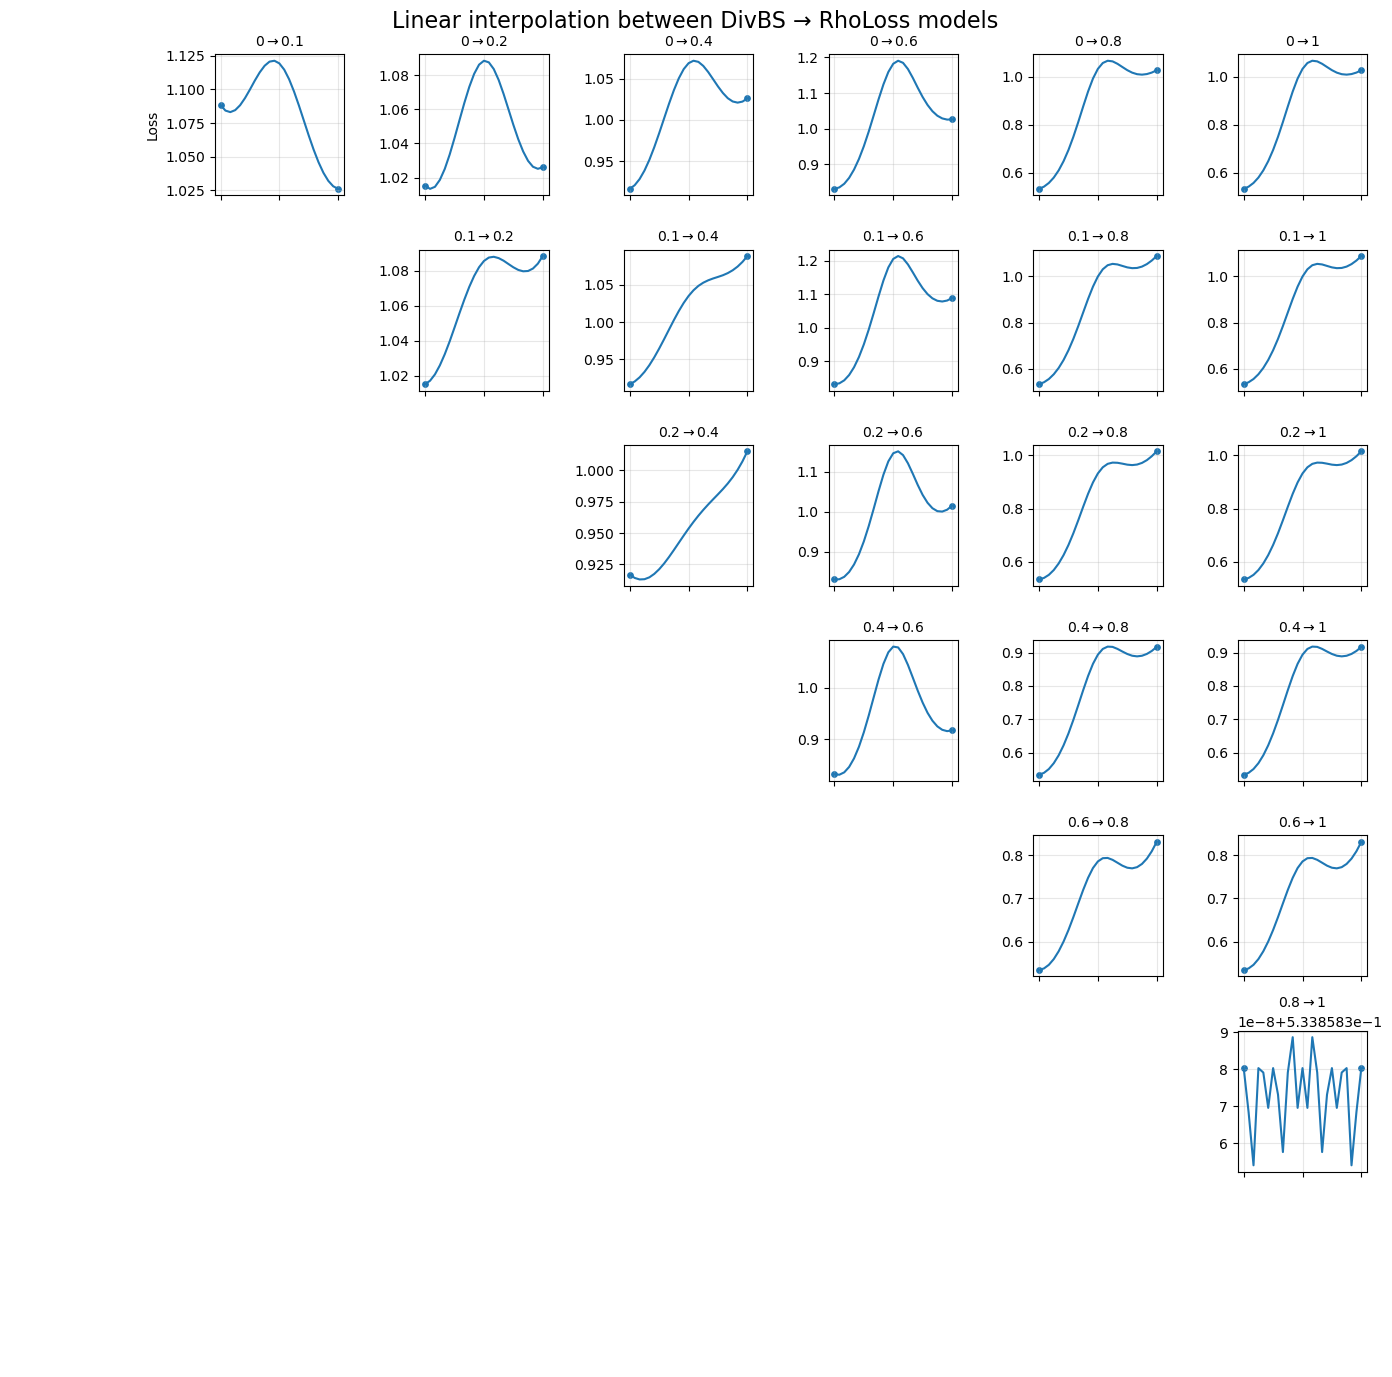

In [11]:
n = len(thresholds)
fig, axes = plt.subplots(
    n,
    n,
    figsize=(14, 14),
    sharex=True,
    sharey=False,
)

for i in range(n):
    for j in range(n):

        ax = axes[i, j]

        if i >= j:
            # Diagonal and lower triangle are unused
            ax.axis("off")
            continue

        thr1 = thresholds[i]
        thr2 = thresholds[j]

        loss = curves[(thr1, thr2)]

        ax.plot(t, loss)

        # Mark the two endpoints
        ax.scatter(
            [t[0], t[-1]],
            [loss[0], loss[-1]],
            s=15,
        )

        ax.set_title(
            rf"${thr1:g} \rightarrow {thr2:g}$",
            fontsize=10,
        )

        ax.grid(alpha=0.3)

        # Only put x labels on bottom row
        if i == n - 1:
            ax.set_xlabel(r"$t$")

        # Only put y labels on left side
        if j == 1:
            ax.set_ylabel("Loss")

fig.suptitle(
    "Linear interpolation between DivBS → RhoLoss models",
    fontsize=16,
)

fig.tight_layout()

plt.show()

In [12]:
fig
fig.savefig(
    "../interpolation/big_plots/train_interpolation_triangular.png",
    dpi=300,
    bbox_inches="tight",
)
